In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langchain_core.prompts import PromptTemplate 
from transformers import pipeline 
from typing import TypedDict
from dotenv import load_dotenv 

C:\Users\shrey\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
pipe = pipeline(
      "text-generation",
      model="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
      max_new_tokens=150,
      temperature=0.5,
)

model = HuggingFacePipeline(pipeline=pipe)

Device set to use cpu


In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [18]:
def create_outline(state: BlogState)->BlogState:
    #fetch title
    title = state['title']

    #call llm gen outline
    prompt=PromptTemplate.from_template(
        'Generate a detailed outline for a blog on the topic -{title}'
    )
    formatted_prompt= prompt.format(title=state["title"])

    #update state
    result=model.invoke(formatted_prompt)

    return {"title": title,
        "outline": result,
        "content": ""}



In [19]:
def create_blog(state: BlogState)->BlogState:
    title=state['title']
    outline = state['outline']


    prompt=PromptTemplate.from_template(
       'Write a detailed blog on the title -{title} using the following outline \n {outline}'
    )
    formatted_prompt= prompt.format(title=state["title"],outline=state["outline"])

    #update state
    result=model.invoke(formatted_prompt)

    return {"title": title,
        "outline": outline,
        "content": result}

    

In [20]:
graph=StateGraph(BlogState)

#nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)

#edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)

workflow=graph.compile()

In [21]:
initial_state={'title': 'Rise of AI in India',"outline":"","content":""}
final_state=workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'Generate a detailed outline for a blog on the topic -Rise of AI in India -How AI is transforming various sectors, including healthcare, education, and agriculture? -Examples of successful AI-led initiatives in India, including those in healthcare, education, and agriculture? -Impact of AI on employment, job opportunities, and the economy of India? -Future of AI in India, including potential challenges and opportunities? -Conclusion: Summary and takeaways.', 'content': 'Write a detailed blog on the title -Rise of AI in India using the following outline \n Generate a detailed outline for a blog on the topic -Rise of AI in India -How AI is transforming various sectors, including healthcare, education, and agriculture? -Examples of successful AI-led initiatives in India, including those in healthcare, education, and agriculture? -Impact of AI on employment, job opportunities, and the economy of India? -Future of AI in India, including potential 

In [23]:
print(final_state['outline'])

Generate a detailed outline for a blog on the topic -Rise of AI in India -How AI is transforming various sectors, including healthcare, education, and agriculture? -Examples of successful AI-led initiatives in India, including those in healthcare, education, and agriculture? -Impact of AI on employment, job opportunities, and the economy of India? -Future of AI in India, including potential challenges and opportunities? -Conclusion: Summary and takeaways.


In [24]:
print(final_state['content'])

Write a detailed blog on the title -Rise of AI in India using the following outline 
 Generate a detailed outline for a blog on the topic -Rise of AI in India -How AI is transforming various sectors, including healthcare, education, and agriculture? -Examples of successful AI-led initiatives in India, including those in healthcare, education, and agriculture? -Impact of AI on employment, job opportunities, and the economy of India? -Future of AI in India, including potential challenges and opportunities? -Conclusion: Summary and takeaways.


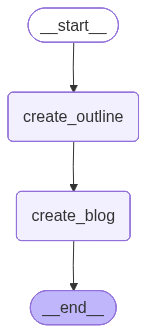

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())